In [1]:
%load_ext autoreload
%autoreload 2

In [2]:


import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

import sys, os
sys.path.append("../../src/")

from network import FeedForward


* how broad should I tuning be?
* what is the effect of I tuning width on the tuning curve of E neurons?
* how strong should the co-tuning of E and I be? what is the effect of co-tuning on the tuning curve of E neurons?

## Effect of I tuning width on E tuning width


In [22]:

i_tuning_scale =  np.linspace(2, 4, 20) # Example scale for i_width
tuning_width_results = []
for i_width in tqdm(i_tuning_scale):
    # setup network and run with this i_width
    net = FeedForward(vars_if_mean=i_width, inh="on")

    tuning_curves, tuning_widths = net.estimate_initial_tuning_width()

    tuning_width_results.append((i_width, tuning_widths))
    # evaluate breadth of E tuning and store results
    mean_tuning_width = np.mean(tuning_widths)
    # print(f"i_width: {i_width}, mean tuning width: {mean_tuning_width}")

  0%|          | 0/20 [00:00<?, ?it/s]

setting seed: 100


  5%|▌         | 1/20 [00:01<00:30,  1.58s/it]

setting seed: 100


 10%|█         | 2/20 [00:03<00:27,  1.56s/it]

...

 90%|█████████ | 18/20 [00:26<00:02,  1.49s/it]

setting seed: 100


 95%|█████████▌| 19/20 [00:28<00:01,  1.53s/it]

setting seed: 100


100%|██████████| 20/20 [00:29<00:00,  1.49s/it]


/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_6938/4055660555.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(tuning_widths_list, labels=[f"{i_width:.2f}" for i_width in i_widths], patch_artist=True)


<Figure size 1500x1200 with 0 Axes>

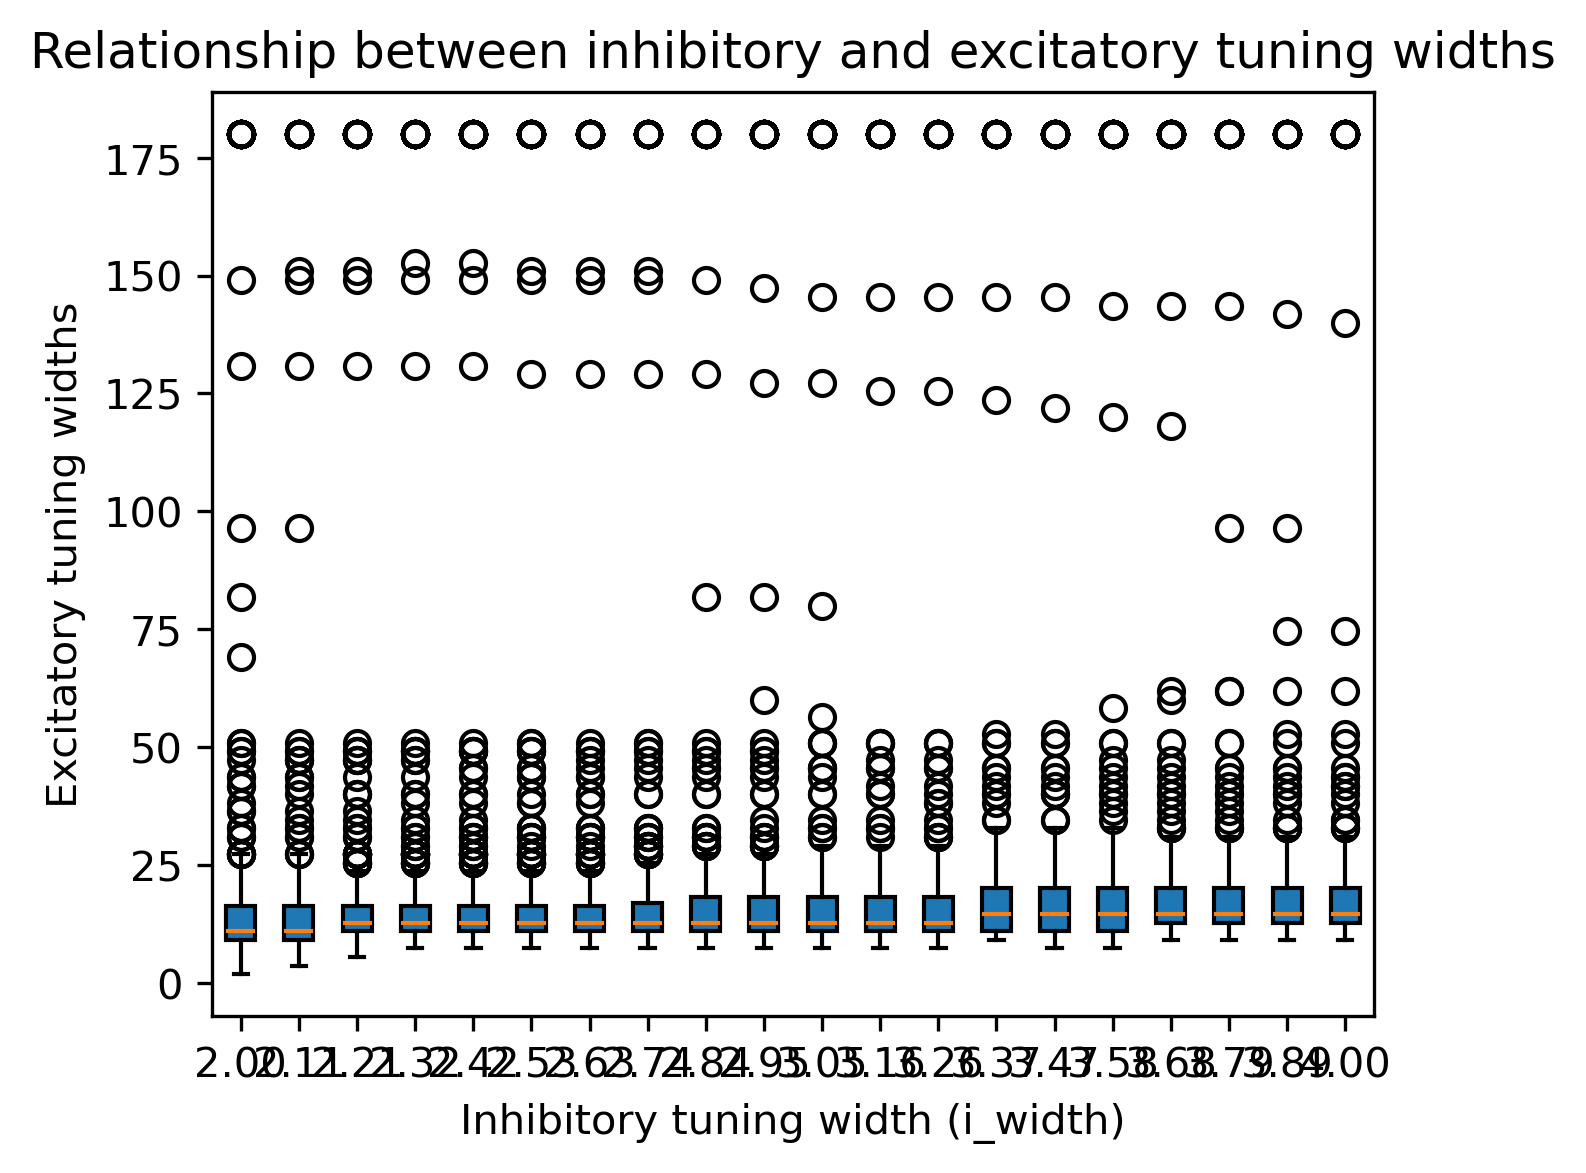

In [31]:
plt.figure(dpi=300, figsize=(5, 4))

# make a box plot of tuning widths vs i_width
plt.figure(dpi=300, figsize=(5, 4))
i_widths = [result[0] for result in tuning_width_results]
tuning_widths_list = [result[1] for result in tuning_width_results]
plt.boxplot(tuning_widths_list, labels=[f"{i_width:.2f}" for i_width in i_widths], patch_artist=True)
plt.xlabel("Inhibitory tuning width (i_width)")
plt.ylabel("Excitatory tuning widths")
plt.title("Relationship between inhibitory and excitatory tuning widths")
plt.show()

### Effect of I to E width on E tuning width

In [5]:
vars_ei_means_scale = np.linspace(2, 4, 20)
tuning_width_results = []

for vars_ei_mean in tqdm(vars_ei_means_scale):
    net = FeedForward(vars_ei_mean=vars_ei_mean, inh="on")
    tuning_curves, tuning_widths = net.estimate_initial_tuning_width()
    # tuning_width_results.append((vars_ei_mean, tuning_widths))
    mean_tuning_width = np.mean(tuning_widths)
    print(f"vars_ei_mean: {vars_ei_mean}, mean tuning width: {mean_tuning_width}")

  0%|          | 0/20 [00:00<?, ?it/s]

setting seed: 100


  5%|▌         | 1/20 [00:01<00:27,  1.46s/it]

vars_ei_mean: 2.0, mean tuning width: 28.64727272727273
setting seed: 100


 10%|█         | 2/20 [00:02<00:26,  1.45s/it]

...

vars_ei_mean: 3.789473684210526, mean tuning width: 33.04363636363637
setting seed: 100


 95%|█████████▌| 19/20 [00:28<00:01,  1.50s/it]

vars_ei_mean: 3.894736842105263, mean tuning width: 33.39636363636364
setting seed: 100


100%|██████████| 20/20 [00:29<00:00,  1.48s/it]

vars_ei_mean: 4.0, mean tuning width: 33.37090909090909


In [7]:
# Combined heatmap of E tuning breadth as a function of both I tuning breadth and I-E tuning breadth

vars_if_means_scale =  np.linspace(2, 4, 20) # Example scale for i_width
vars_ei_means_scale = np.linspace(2, 4, 20)

tuning_width_results = np.zeros((len(vars_if_means_scale), len(vars_ei_means_scale)))

for i, vars_if_mean in enumerate(tqdm(vars_if_means_scale)):
    for j, vars_ei_mean in enumerate(vars_ei_means_scale):
        net = FeedForward(vars_if_mean=vars_if_mean, vars_ei_mean=vars_ei_mean, inh="on")
        tuning_curves, tuning_widths = net.estimate_initial_tuning_width()
        mean_tuning_width = np.mean(tuning_widths)
        tuning_width_results[i, j] = mean_tuning_width
        # print(f"vars_if_mean: {vars_if_mean}, vars_ei_mean: {vars_ei_mean}, mean tuning width: {mean_tuning_width}")

  0%|          | 0/20 [00:00<?, ?it/s]

setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100


  5%|▌         | 1/20 [00:29<09:13, 29.11s/it]

setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100


 10%|█         | 2/20 [00:57<08:40, 28.92s/it]

...

 90%|█████████ | 18/20 [35:25<07:58, 239.38s/it]

setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100


 95%|█████████▌| 19/20 [35:51<02:55, 175.24s/it]

setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100
setting seed: 100


100%|██████████| 20/20 [36:17<00:00, 108.87s/it]


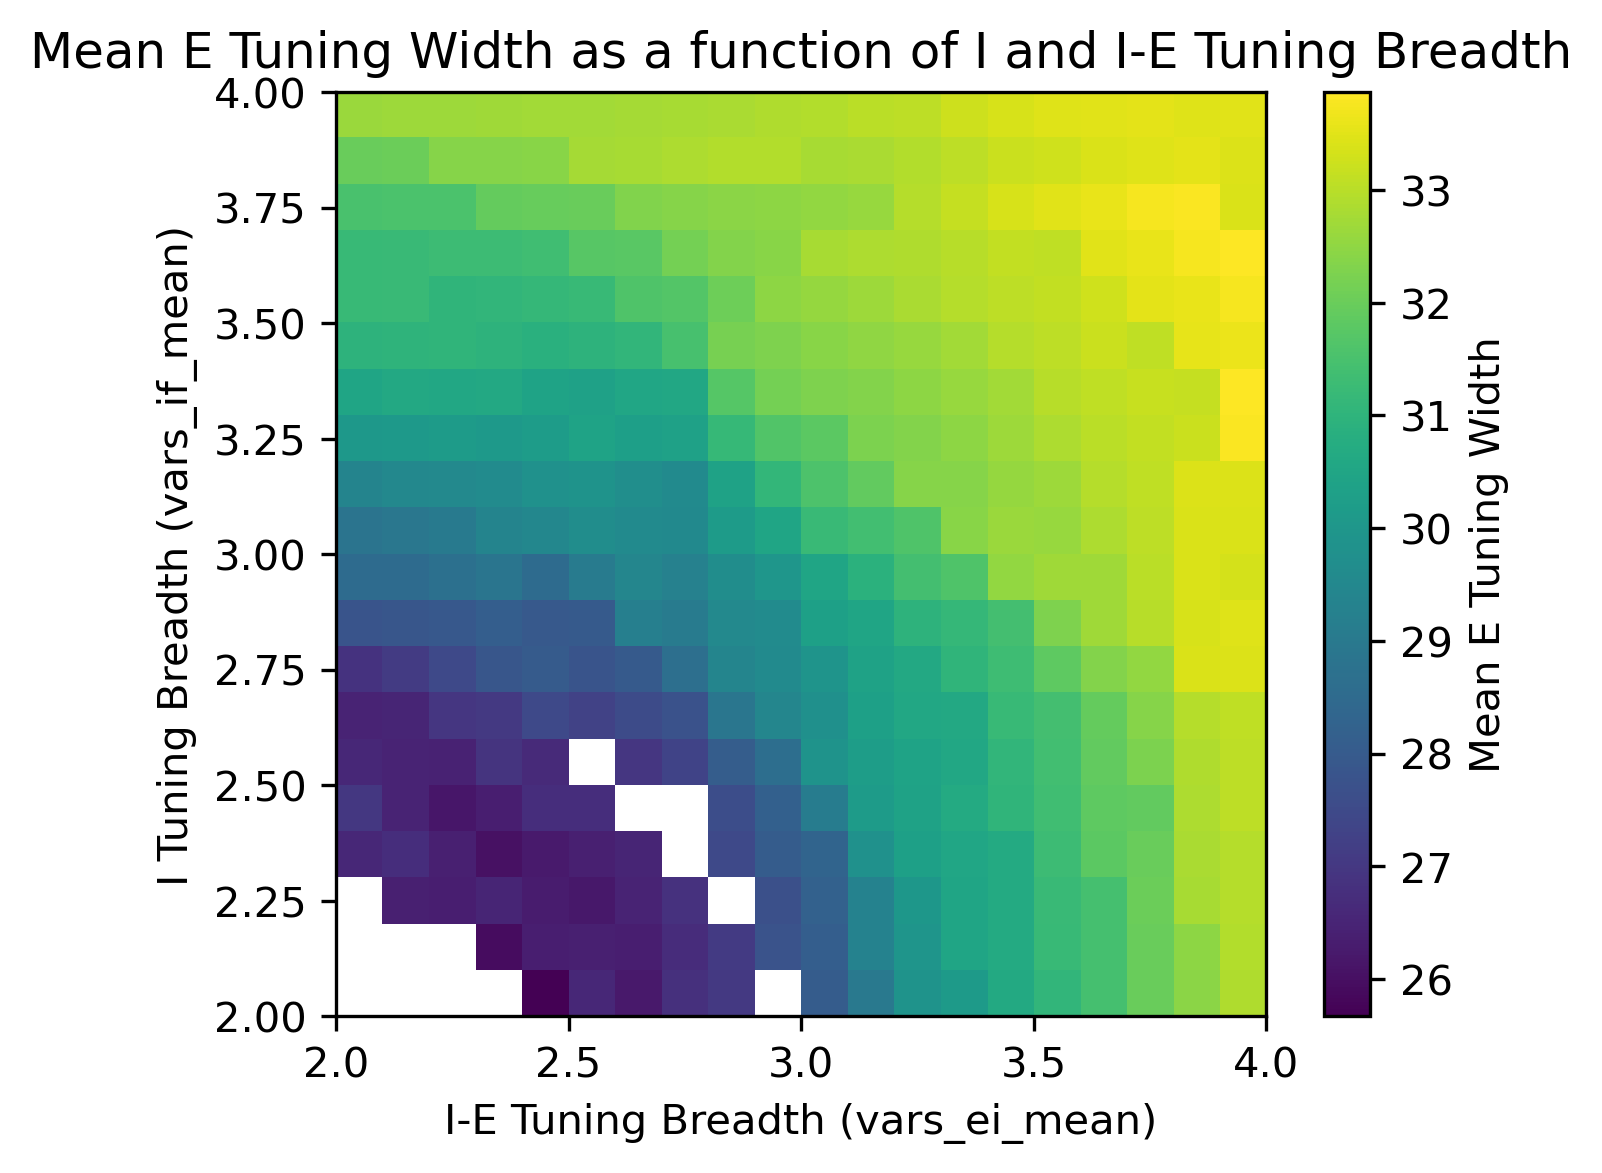

In [12]:
plt.figure(dpi=300, figsize=(5, 4))
plt.imshow(tuning_width_results, extent=(vars_ei_means_scale[0], vars_ei_means_scale[-1], vars_if_means_scale[0], vars_if_means_scale[-1]), origin='lower', aspect='auto')

plt.colorbar(label='Mean E Tuning Width')
plt.xlabel('I-E Tuning Breadth (vars_ei_mean)')
plt.ylabel('I Tuning Breadth (vars_if_mean)')
plt.title('Mean E Tuning Width as a function of I and I-E Tuning Breadth')
plt.show()

### Sanity check, plot actual tuning curves and activity for any combination of vars

In [ ]:
vars_ei_mean = 3
vars_if_mean = 3

net = FeedForward(vars_if_mean=vars_if_mean, vars_ei_mean=vars_ei_mean, inh="on")
tuning_curves, tuning_widths = net.estimate_initial_tuning_width()


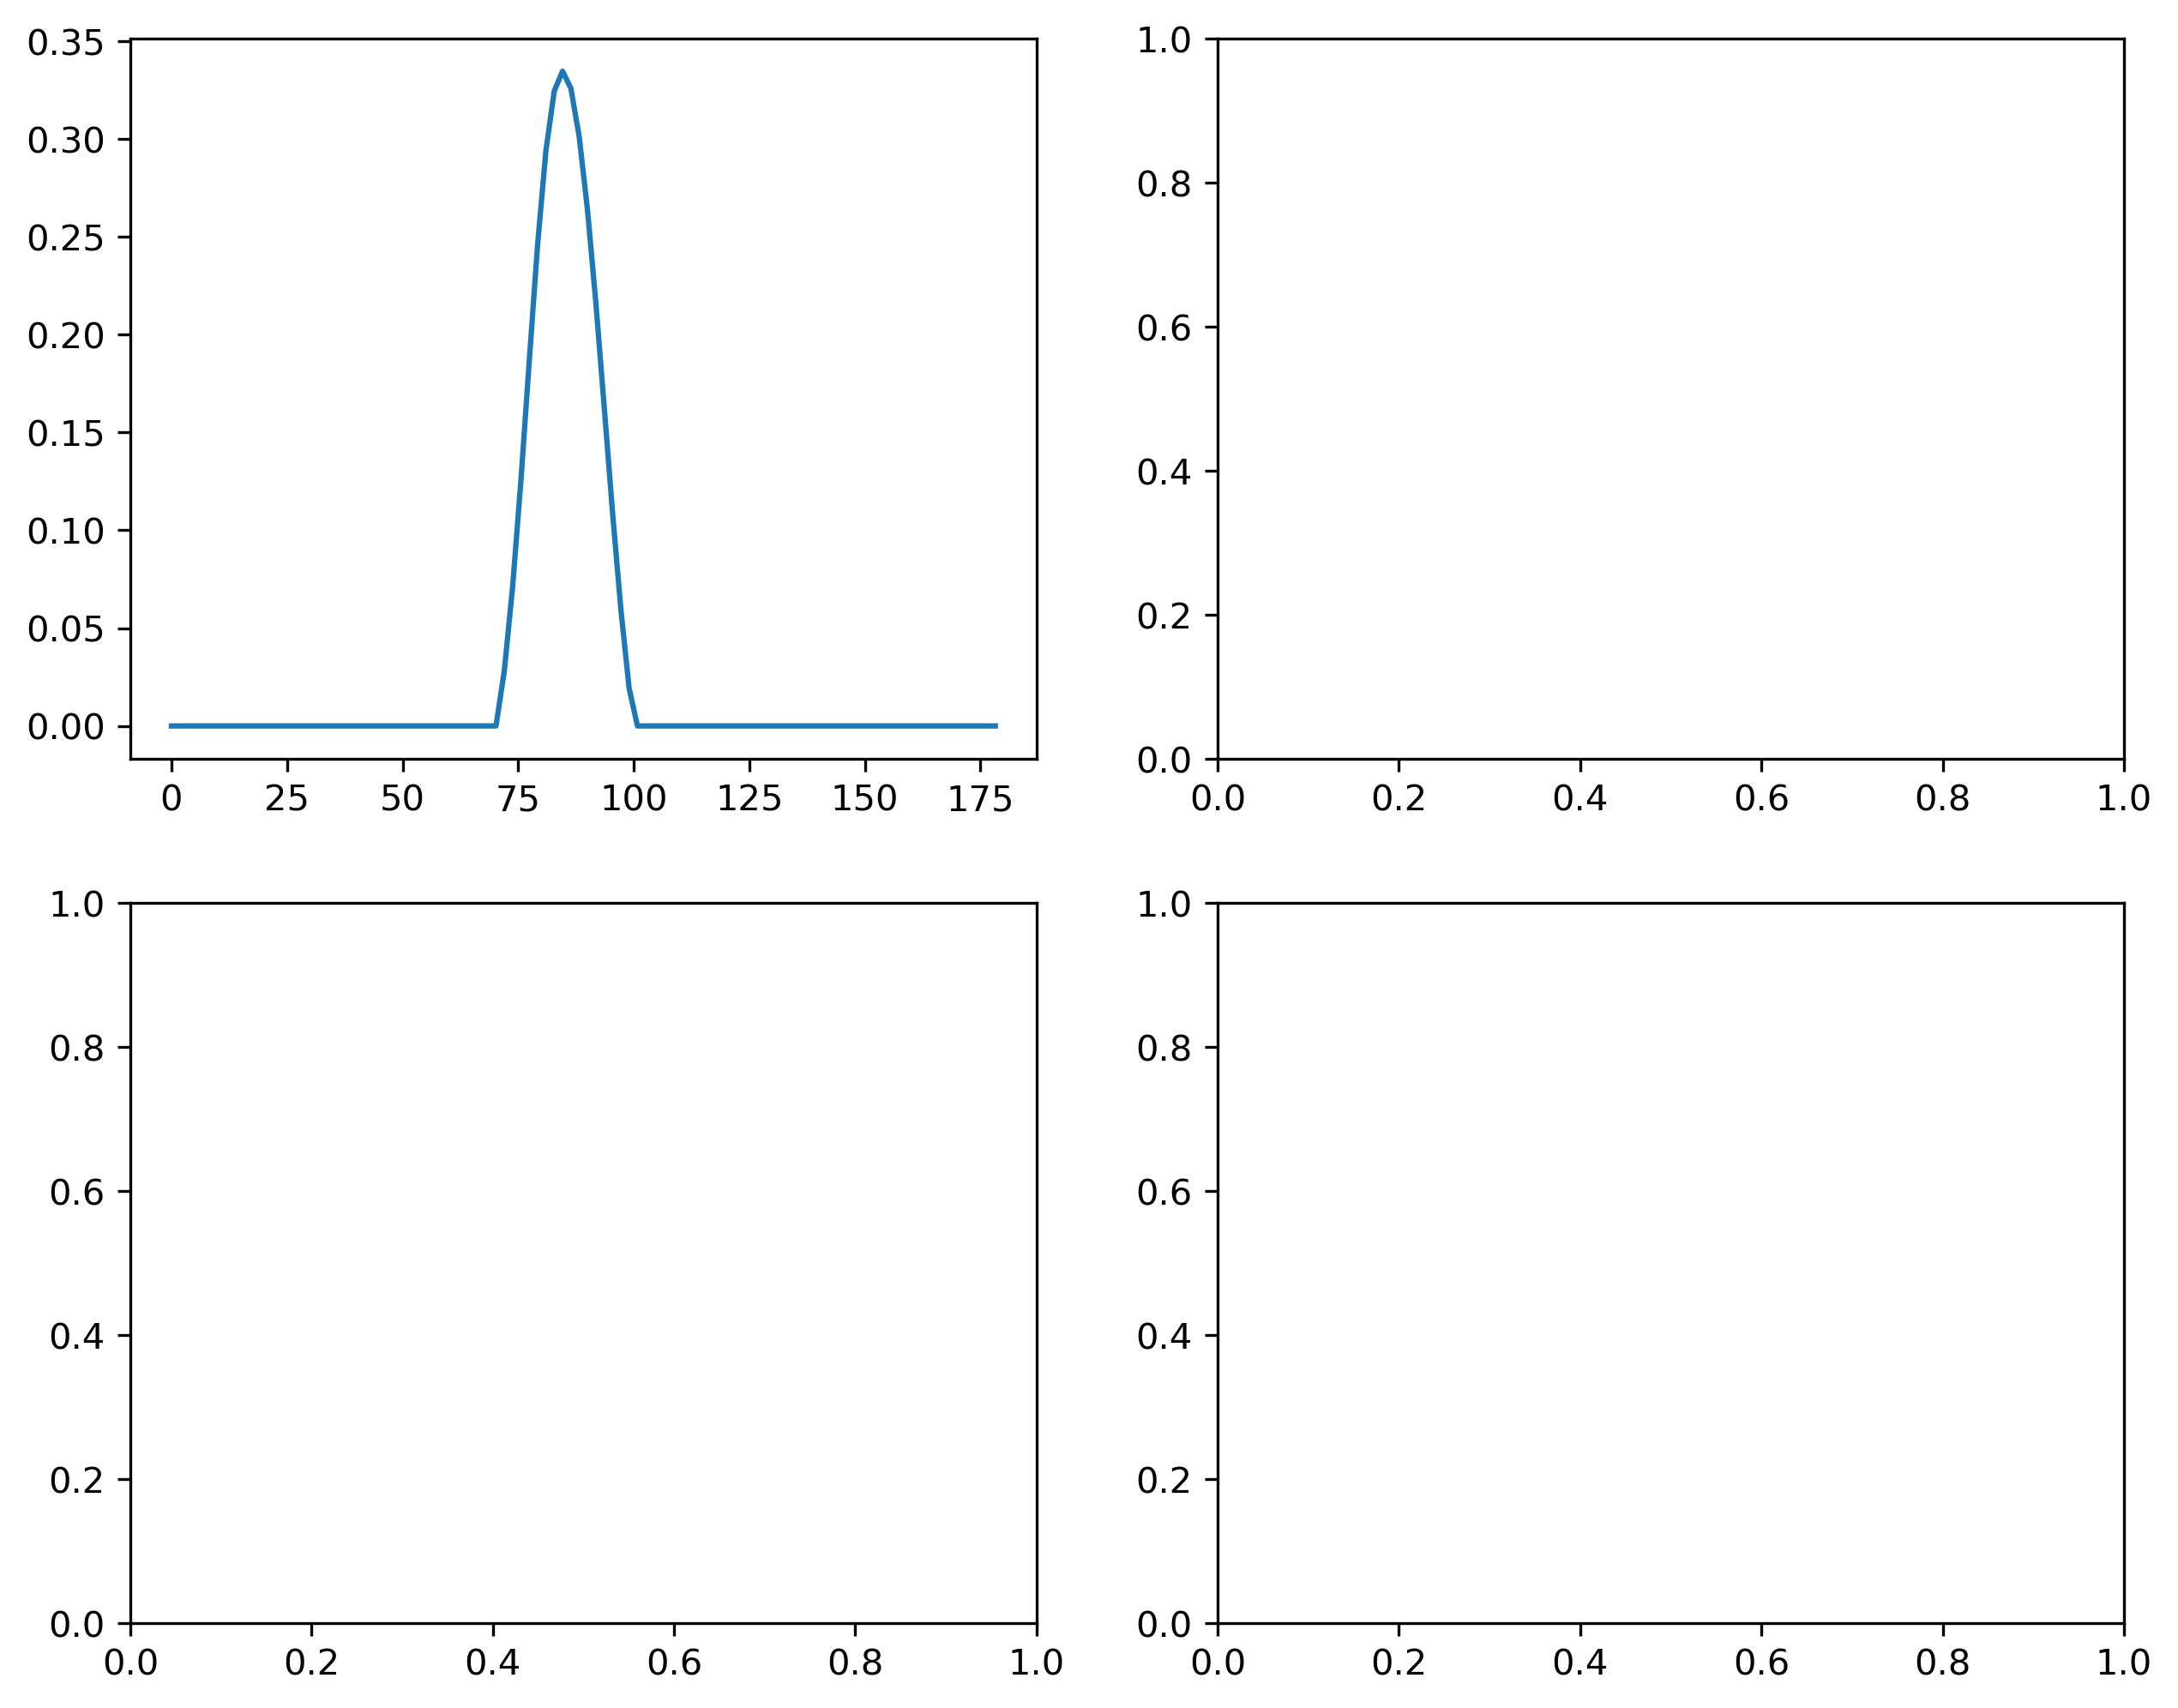

In [ ]:
probe_angle = 50
cell_idx = 240

theta_list = np.linspace(0, 180, net.n_test_angles, endpoint=False)

fig, axs = plt.subplots(2, 2, figsize=(10, 8), dpi=300)

axs[0, 0].plot(theta_list, tuning_curves[cell_idx])
# Plot activity of the I popuation to this probe angle for multiple i_width values

axs[0, 0].plot()


In [54]:
net_i_width_1 = FeedForward(vars_if_mean=2, inh="on")
net_i_width_2 = FeedForward(vars_if_mean=3, inh="on")
net_i_width_3 = FeedForward(vars_if_mean=4, inh="on")

setting seed: 100
setting seed: 100
setting seed: 100


In [55]:
net = FeedForward(inh="on")

setting seed: 100


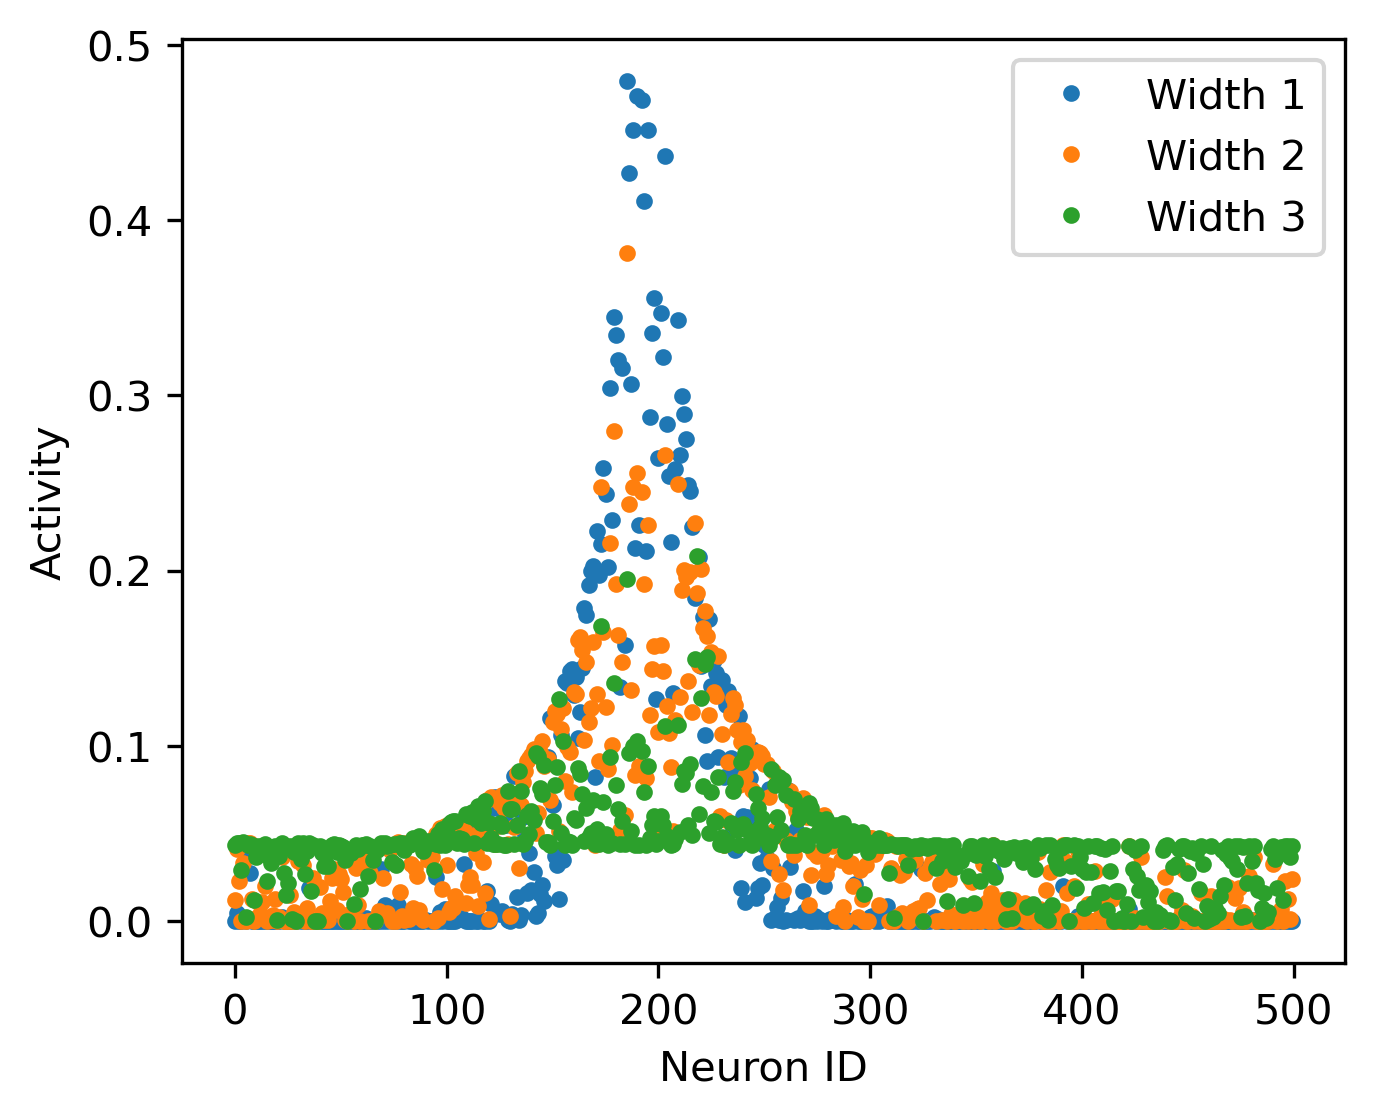

In [56]:
probe_angle = 70
# estimate activity at this probe angle for the population

_, r_i_1, _ = net_i_width_1.estimate_initial_activity(probe_angle=probe_angle)
_, r_i_2, _ = net_i_width_2.estimate_initial_activity(probe_angle=probe_angle)
_, r_i_3, _ = net_i_width_3.estimate_initial_activity(probe_angle=probe_angle)


plt.figure(dpi=300, figsize=(5, 4))
plt.plot(r_i_1, '.', label='Width 1')
plt.plot(r_i_2, '.', label='Width 2')
plt.plot(r_i_3, '.', label='Width 3')
plt.xlabel("Neuron ID")
plt.ylabel("Activity")
plt.legend()

In [50]:
tuning_curve_inh = net.estimate_initial_tuning_inh()

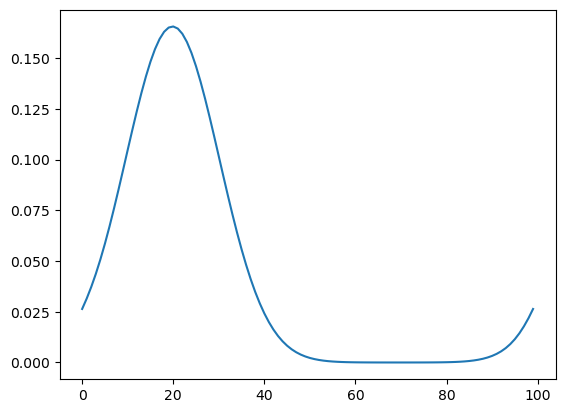

In [52]:
plt.plot(tuning_curve_inh[100])